**Ellipse Detection Algorithm Demo**

This notebook is a demo of the concentric ellipse detection algorithm developed for pose estimation using a satellite's launch adapter ring (LAR) feature. The algorithm uses no apriori knowledge of the client/chaser relative pose, although an optional tracking mode is available, which improves robustness and comptational efficiency on a trajectory with 1Hz image sampling. The algorithm is optimized for operation at a range of 2 meters, but has the possibility to run between 4 meters and 1.5 meters. 

**Ellipse detection pipeline overview**
1. **Edge detection** - Canny edge detector and edge thinning.
2. **Countour extraction** - Selection of a region of interest around the client's LAR and continuous contour extraction from edge map.
3. **Arc segmentation** - Contours are split at curvature inflection points and points where the curvature radius changes abruptly. The remaing arcs are curvature and convexity consitent.
4. **Arc filtering** - Near-straight arcs and arcs whose radius of curvature falls outisde the expected range are removed. If a large number of points remains in the arc pool, arcs are decimated such that the pool contains at most 3000 points.
5. **Robust ellipse fitting** - The core of the algorithm logic: arc-constrained RANSAC algorithm. Arc pairs are drawn from the arc pool exhaustively and from each pair a sample of 5 points is drawn, defining an ellipse model. Ellipse models are evaluated against expected ranges (min/max semi-major axis, eccentricity and, if tracking mode is used, centre bounding box). Ellipse models passing these checks are evaluated against the full arc pool, the ellipse model containing the most inliers at each round is retained. The RANSAC algorithm is run until 3 ellipse models with sufficiently different smi-major axes are retained or until the maximum number of restarts is reached. The output is a least-squares refit on all inlier points.
6. **Concentric ellipse pair selection** - Of all the retained ellipses, the pair most consistent with two coplanar concentric circles (matching eccentricity, center and expected semi-major axis ratio) is selected.
7. **Ellipse refinement** - Both ellipses are coarsely then finely refit on the full edge map (before any segmentation, filtering or decimation) to take advantage of true inliers which failed to pass the filters 

**Tracking mode**

When enabled, the previous frame's fitted ellipse and estimated pose are used to predict a search region for the current frame: the prior depth estimate converts a world-space search radius of 5 cm into a pixel bounding box, and RANSAC candidates are rejected if their centre falls outside it before the residual evaluation runs. This improves both robustness (less likely to fit to a suprious background feature) and runtime (bad ellipse models are rejected before the costly residual evaluation). If the previous frame's fit is unavailable, the algorithm falls back one further frame with a widened search radius, and falls back to full-frame detection if that also is not available. Tracking mode can be tested in this notebook by running on the DOR dataset, which contains a series of images at 1Hz frequency along a reference RPO trajectory.

**Pose estimation pipeline overview**
1. **Ellipse-to-circle correspondence** - For each refit ellipse (outer and inner ring), inlier edge points are mapping onto a unit circle. The recovered angular parameter is then used to place each inlier on the corresponding 3D ring circle (radius R_OUTER or R_INNER, lying in the ring's local Z=0 plane), yielding a set of 2D-3D correspondences per ring.
2. **Per-ring PnP solve** - The 2D-3D correspondences for each ring are solved independently with OpenCV's PnP solver (`solvePnPGeneric`), which returns candidate rotation/translation pairs; the solution with positive depth (target in front of the camera) is kept.
3. **Reprojection error evaluation** - The object points are reprojected through the estimated pose and compared to the original image points to obtain a mean reprojection error as a confidence metric
4. **Pose output** - Translation vector, rotation matrix and reprojection error are produced independently for the outer and inner ring. The pose estimation from the outer ellipse is compared to the ground truth to compute the error

Author: Florian Mellab

**Parameter initialisation and image loading**

In [12]:
from pathlib import Path

DATASET = "CPO"   # Dataset selection: "CPO_scaled", "CPO", "DOR" or "CPO_dataset_X"

DATASET_CONFIGS = {
    "CPO_scaled": dict(
        file_path = r"CPO_scaled_drift_dataset/scene_0036.tiff",
        metadata_path = Path(r"CPO_scaled_drift_dataset/metadata.json"),
        R_OUTER=0.080*7.4, R_INNER=0.066*7.4,
        dmin=1.5, dmax=4.0,
        min_curvature=0.2,
        tracking_ellipse_dir=None,
        tracking_pose_dir=None,
        frame_prefix=None,
        camera="AuricamD80",
    ),
    "CPO": dict(
        file_path=Path(r"CPO_drift_dataset/scene_0131.tiff"),
        metadata_path=Path(r"CPO_drift_dataset/metadata.json"),
        R_OUTER=0.080, R_INNER=0.066,
        dmin=1.5, dmax=4.0,
        min_curvature=0.3, 
        tracking_ellipse_dir=None,
        tracking_pose_dir=None,
        frame_prefix=None,
        camera="AuricamD80",
    ),
    #Note: Dataset DOR is not provided with this Jupyter notebook for confidentiality reasons
    "DOR": dict(
        file_path=Path(r"DOR_dataset/rendering/WCAM1_AURICAM_3.png"),
        metadata_path=None,
        R_OUTER=0.597, R_INNER=0.553,
        dmin=1.5, dmax=4.0,
        min_curvature=0.2,
        tracking_ellipse_dir=Path(r"DOR_dataset/detections"),
        tracking_pose_dir=Path(r"DOR_dataset/detections"),
        frame_prefix="WCAM1_AURICAM",
        camera="AuricamD80",
        #DOR dataset specific tuning
        canny_low = 60, 
        curvature_window=11, 
    ),
    #Note: Dataset X contains physical images from the GRALS facilities and is not provided with this Jupyter notebook for confidentiality reasons
    "CPO_dataset_X": dict(
        file_path=Path(r"CPO_dataset_X\1 - DATA\Session_2\shadows\batch_SDW1\run2\raws_tracking\dataset_X_scene_3.png"),
        metadata_path=None,
        R_OUTER=0.080, R_INNER=0.066,
        dmin=1.0, dmax=4.0,
        min_curvature=0.3,
        tracking_ellipse_dir=None,
        tracking_pose_dir=None,
        frame_prefix=None,
        camera="camera_X",
    ),
}

cfg = DATASET_CONFIGS[DATASET]
sma_ratio_nominal = cfg["R_INNER"] / cfg["R_OUTER"]

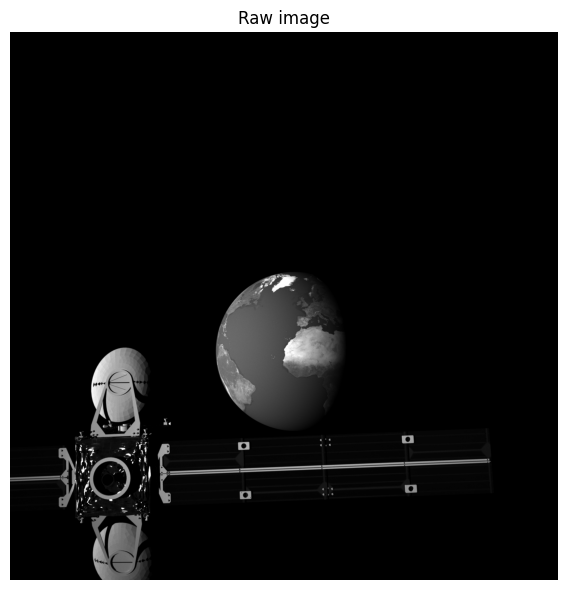

In [13]:
import cv2 as cv
from tracking_mode import read_image, visualize

img = read_image(cfg["file_path"])

visualize(img, title="Raw image")

**Edge map and search area**

Tracking mode: inactive (full-frame search)


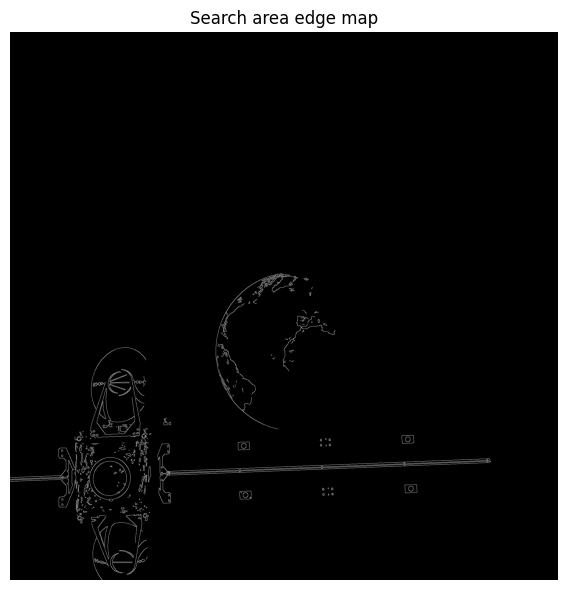

In [14]:
import numpy as np
from tracking_mode import find_edges, absolute_size_filter, refine_search_area_symmetric, refine_search_area_symmetric, visualize, init_tracking_mode

# --- Edge detection + thinning ---
canny_low = cfg["canny_low"] if DATASET == "DOR" else 100
edges = find_edges(img, low=canny_low, high=200)
edges = cv.ximgproc.thinning(edges, thinningType=cv.ximgproc.THINNING_ZHANGSUEN)

# --- Camera intrinsics (dataset-dependent) ---
if cfg["camera"] == "camera_X":
    # Camera parameters - CamX
    focal_length = 6e-3  # m
    pixel_pitch = 2.2e-6 # m
    image_size = [2590, 1942]

    #Parameters based on camera noise
    max_extra_rounds = 3
    tolerance_eccentricity = 0.20
    max_radius_ratio = 3.0

    fx = focal_length / pixel_pitch
    fy = focal_length / pixel_pitch

elif cfg["camera"] == "AuricamD80":
    # Camera parameters - AuricamD80
    image_size = [2048, 2048]
    # image_size = [1024, 1024] #Binned
    square_fov_deg = 56.6

    #Parameters based on camera noise
    max_extra_rounds = 2
    tolerance_eccentricity = 0.15
    max_radius_ratio = 2.0

    fx = (image_size[0] / 2.0) / np.tan(np.deg2rad(square_fov_deg) / 2.0)
    fy = fx

# --- Initialise tracking prior from the previous frame's detection if configured ---
bbox_tracking = None
tracking = None
if cfg.get("tracking_ellipse_dir") is not None and cfg.get("tracking_pose_dir") is not None:
    tracking = init_tracking_mode(
        current_file=cfg["file_path"],
        ellipse_path_dataset=cfg["tracking_ellipse_dir"],
        pose_path_dataset=cfg["tracking_pose_dir"],
        fx=fx,
        R_TRACKING=0.05,
        image_size=image_size,
        frame_prefix=cfg["frame_prefix"],
    )
print("Tracking mode:", "ACTIVE" if tracking is not None else "inactive (full-frame search)")

# --- Depth bounds: around apriori depth if tracking, else the dataset's generic range ---
if tracking is not None:
    depth_margin = 0.5  # metres
    d_min = max(cfg["dmin"], tracking["apriori_depth"] - depth_margin)
    d_max = min(tracking["apriori_depth"] + depth_margin, cfg["dmax"])
else:
    d_min, d_max = cfg["dmin"], cfg["dmax"]

# --- Define LAR physical size bounds
a_outer_max_px, a_outer_min_px, a_inner_max_px, a_inner_min_px = absolute_size_filter(
    fx, R_OUTER=cfg["R_OUTER"], R_INNER=cfg["R_INNER"], d_min=d_min, d_max=d_max
)

# --- Define search area ---
# search_area, (x1, y1, x2, y2) = refine_search_area_symmetric(
#     edges, kernel_size=151, density_threshold=0.05,
#     expected_max_radius_px=a_outer_max_px, margin=1.5*a_outer_max_px
# )
search_area = edges
x1, y1, x2, y2 = 0, 0, img.shape[1], img.shape[0]

visualize(search_area, title="Search area edge map")

# --- Tracking bbox + RANSAC settings (tighter when tracking is active) ---
if tracking is not None:
    x1_bb, y1_bb, x2_bb, y2_bb = tracking["bbox"]
    bbox_tracking = (
        x1_bb - x1,
        y1_bb - y1,
        x2_bb - x1,
        y2_bb - y1,
    )
    residual_threshold_ransac = 0.5
else:
    residual_threshold_ransac = 0.7

**Arc filtering**

Total contours: 723
Arcs after convexity and curvature segmentation : 858
Arcs after collinearity filter: 466
Arcs after radius filter: 31


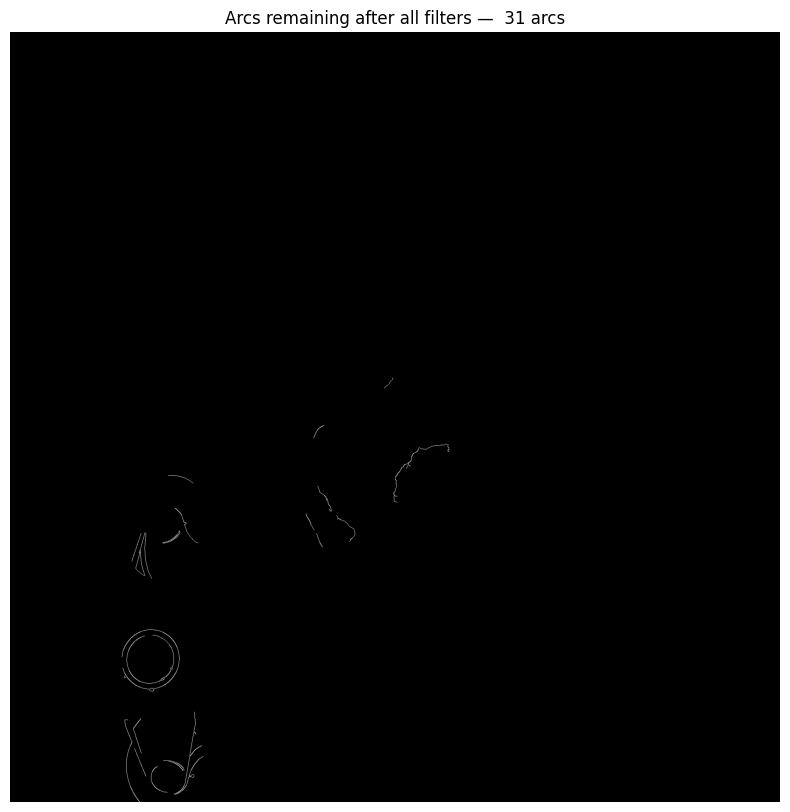

In [15]:
from tracking_mode import find_contours, segment_arcs, segment_arcs_by_curvature_smoothness, filter_collinear_arcs, filter_arcs_by_radius, visualize_arcs

# --- Extract contours from the cropped edge map ---
contours = find_contours(search_area)

# --- Split contours at inflection points to obtain arc fragments ---
curvature_window =cfg["curvature_window"] if DATASET == "DOR" else 31
arcs = segment_arcs(contours=contours, min_arc_length=int(max(5, 0.8*np.sqrt(a_inner_min_px))), curvature_window=curvature_window)

# --- Split contours at points where radius of curvature changes ---
arcs = segment_arcs_by_curvature_smoothness(arcs, max_radius_ratio=max_radius_ratio, min_arc_length=int(max(5, 0.8*np.sqrt(a_inner_min_px))))

# --- Filter near-straight arcs ---
filtered_arcs_collinear = filter_collinear_arcs(arcs, min_curvature=cfg["min_curvature"])

# --- Keep only the arcs within plausible radius bounds ---
min_radius = 0.98*a_inner_min_px
max_radius = 1.67*a_outer_max_px
filtered_arcs_radius, radii = filter_arcs_by_radius(filtered_arcs_collinear, min_radius=min_radius, max_radius=max_radius, max_residual_ratio=0.3)

print("Total contours:", len(contours))
print("Arcs after convexity and curvature segmentation :", len(arcs))
print("Arcs after collinearity filter:", len(filtered_arcs_collinear))
print("Arcs after radius filter:", len(filtered_arcs_radius))

visualize_arcs(filtered_arcs_radius, search_area.shape, title="Arcs remaining after all filters")

**RANSAC ellipse fit**

  Computed decimate density: 0.5689 (total points=5273, target=3000pts)
Total points in pool: 2986
RANSAC round 1: 2986 points remaining, 31 eligible arcs
  Round 1: 465 pairs × 2 samples/pair = 930 trials
  Round 1: evaluated 465 arc pairs
  → Retained [1/3] center=(372.7, 1667.6)  a=64.8  b=62.2  theta=112.6°  inliers=319/2986
RANSAC round 2: 2667 points remaining, 30 eligible arcs
  Round 2: 435 pairs × 2 samples/pair = 870 trials
  Round 2: evaluated 435 arc pairs
  → Retained [2/3] center=(373.2, 1668.0)  a=79.3  b=76.0  theta=110.6°  inliers=407/2667
  Early stop: strict pair found after 2 ellipses (round 2), skipping remaining rounds.


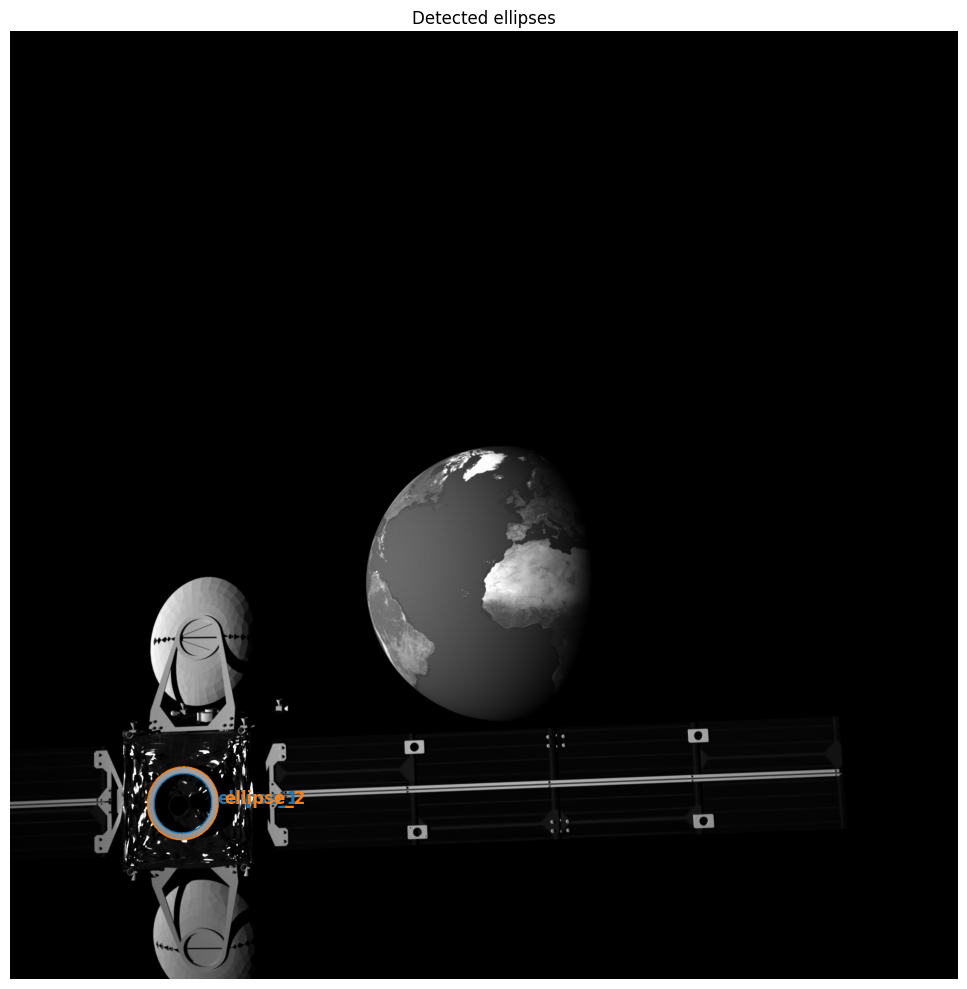

In [16]:
from tracking_mode import compute_target_decimate_density, decimate_arc_uniform_density, fit_ellipses_ransac
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Fit ellipses ---
decimate_density = compute_target_decimate_density(filtered_arcs_radius, target_total_points=3000)
filtered_arcs_for_ransac = [
    decimate_arc_uniform_density(arc, points_per_pixel=decimate_density, min_points=5)
    for arc in filtered_arcs_radius]           

#Define tolerance center wrt a_outer_max_px
tolerance_center = min(a_outer_max_px / 7.5, 80)
min_delta_sma = max(10.0, 0.8*(a_outer_min_px-a_inner_min_px))

# --- RANSAC restarts if no valid pair is found  ---
max_ransac_restarts = 2
retained_ellipses, best_pair, best_overall_ellipse = None, None, None

for attempt in range(max_ransac_restarts):
    retained_ellipses, best_pair, best_overall_ellipse = fit_ellipses_ransac(
        filtered_arcs=filtered_arcs_for_ransac, n_ellipses=3, min_samples=5,
        residual_threshold=residual_threshold_ransac, min_delta_sma=min_delta_sma, max_eccentricity=0.8,
        min_sample_spread=1.6*a_inner_min_px, max_extra_rounds=max_extra_rounds,
        tolerance_eccentricity=tolerance_eccentricity, tolerance_center=tolerance_center,
        a_inner_min_px=a_inner_min_px, a_inner_max_px=a_inner_max_px,
        a_outer_min_px=a_outer_min_px, a_outer_max_px=a_outer_max_px,
        bbox_tracking=bbox_tracking, min_trials=600, max_trials=1000
    )

    if best_pair is not None:
        break
    print(f"Attempt {attempt+1}/{max_ransac_restarts}: no valid pair, retrying...")

if best_pair is None:
    raise RuntimeError(f"No valid ellipse pair found after {max_ransac_restarts} attempts.")

img_crop = img[y1:y2, x1:x2]
n = len(retained_ellipses)
mpl_colors = [cm.tab10(i) for i in range(n)]
cv_colors  = [tuple(int(c * 255) for c in mpl_colors[i][:3])[::-1] for i in range(n)]
labels     = [f"ellipse_{i+1}" for i in range(n)]

if img_crop.max() > 255:
    display = (img_crop / 16).astype(np.uint8)
else:
    display = img_crop.astype(np.uint8)
display_color = cv.cvtColor(display, cv.COLOR_GRAY2BGR)

fig, ax = plt.subplots(figsize=(10, 10))
for i, (xc, yc, a, b, theta, inliers) in enumerate(retained_ellipses):
    cv.ellipse(display_color, (int(round(xc)), int(round(yc))),
            (int(round(a)), int(round(b))), float(np.degrees(theta)),
            0, 360, cv_colors[i], 2)
    ax.annotate(labels[i], xy=(xc, yc), xytext=(xc + a + 10, yc),
                color=mpl_colors[i], fontsize=12, fontweight='bold')
ax.imshow(cv.cvtColor(display_color, cv.COLOR_BGR2RGB))
ax.set_title("Detected ellipses")
ax.axis('off')
plt.tight_layout()
plt.show()


**Ellipse pair refinement**

  joint_refit [outer]: 562 inliers from full edge map
  joint_refit [outer]: center (373.2,1668.0)→(373.3,1668.0)  a 79.3→79.2  b 76.0→76.0  theta 110.6°→108.9°
  joint_refit [inner]: 439 inliers from full edge map
  joint_refit [inner]: center (372.7,1667.6)→(372.6,1667.7)  a 64.8→64.7  b 62.2→62.2  theta 112.6°→112.6°
  joint_refit [outer]: 276 inliers from full edge map
  joint_refit [outer]: center (373.3,1668.0)→(373.3,1668.0)  a 79.2→79.2  b 76.0→76.0  theta 108.9°→108.5°
  joint_refit [inner]: 223 inliers from full edge map
  joint_refit [inner]: center (372.6,1667.7)→(372.6,1667.7)  a 64.7→64.7  b 62.2→62.2  theta 112.6°→112.6°


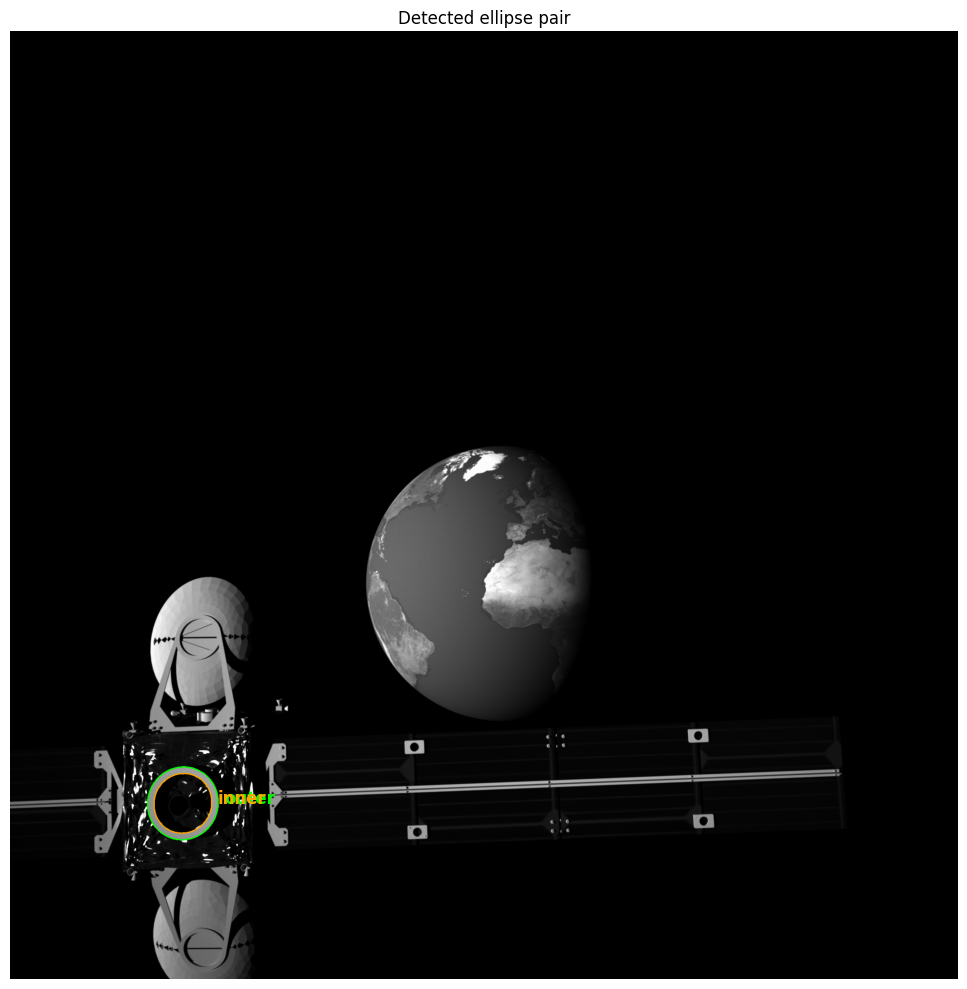

In [17]:
from tracking_mode import joint_refit_ellipse_pair, angular_coverage_deg, normalized_residual

# --- Refit ellipse pair ---
refitted_pair = joint_refit_ellipse_pair(best_pair=best_pair, edges=edges, x_offset=int(x1), y_offset=int(y1), residual_threshold=1.0)
refitted_pair = joint_refit_ellipse_pair(best_pair=refitted_pair, edges=edges, x_offset=int(x1), y_offset=int(y1), residual_threshold=0.3)

# --- Reject if outer/inner centers disagree too much after refit ---
(xc_outer, yc_outer, *_rest_outer) = refitted_pair[0]
(xc_inner, yc_inner, *_rest_inner) = refitted_pair[1]
center_dist = np.sqrt((xc_outer - xc_inner)**2 + (yc_outer - yc_inner)**2)
if center_dist > tolerance_center / 3:
    print(f"WARNING: post-refit center_dist={center_dist:.2f}px exceeds threshold "
          f"({tolerance_center/3:.2f}px) — fit is unreliable.")

# --- Visualise ellipses on cropped original image ---
img_crop = img[y1:y2, x1:x2]
mpl_colors = ['lime', 'orange']
cv_colors   = [(0, 255, 0), (0, 165, 255)]
labels      = ["outer", "inner"]

display  = (img_crop / 16).astype(np.uint8) if img_crop.max() > 255 \
        else img_crop.astype(np.uint8)
display_color = cv.cvtColor(display, cv.COLOR_GRAY2BGR)

fig, ax = plt.subplots(figsize=(10, 10))
for i, (xc, yc, a, b, theta, _inliers) in enumerate(refitted_pair):
    cv.ellipse(
        display_color,
        (int(round(xc)), int(round(yc))),
        (int(round(max(a, b))), int(round(min(a, b)))),
        float(np.degrees(theta)),
        0, 360,
        cv_colors[i], 2,
    )
    ax.annotate(
        labels[i], xy=(xc, yc),
        xytext=(xc + max(a, b) + 10, yc),
        color=mpl_colors[i], fontsize=12, fontweight="bold",
    )
ax.imshow(cv.cvtColor(display_color, cv.COLOR_BGR2RGB))
ax.set_title(f"Detected ellipse pair")
ax.axis("off")
plt.tight_layout()
plt.show()

ellipse_data = {}
for label, (xc, yc, a, b, theta, inlier_pts) in zip(labels, refitted_pair):
    # Fit-quality metrics: how well-supported is this individual
    # ellipse's size/shape, independent of the other ellipse in the pair
    if len(inlier_pts) >= 5:
        coverage_deg = angular_coverage_deg(inlier_pts, xc, yc, n_bins=36)
        resid_norm   = normalized_residual(inlier_pts, xc, yc, a)
    else:
        coverage_deg = 0.0
        resid_norm   = np.inf

    ellipse_data[label] = {
        "xc":       float(xc),
        "yc":       float(yc),
        "a":        float(a),
        "b":        float(b),
        "theta_deg": float(np.degrees(theta)),
        "inliers": inlier_pts.astype(np.float32),
        "n_inliers": int(len(inlier_pts)),
        "angular_coverage_deg": float(coverage_deg),
        "normalized_residual": float(resid_norm),
        # offsets to map back to full-image coordinates
        "x_offset": int(x1),
        "y_offset": int(y1),
    }

    if tracking is not None:
        np.save(cfg["tracking_ellipse_dir"] / f"{cfg['file_path'].stem}_ellipses.npy", ellipse_data)

**Pose estimation**

In [18]:
from pose_estimation import compute_pose
import re
import json

K = np.array([
    [fx, 0,  image_size[0] / 2],
    [0,  fx, image_size[1] / 2],
    [0,  0,   1]
], dtype=np.float64)

pose_data = compute_pose(
                        ellipse_data, K,
                        R_OUTER = cfg["R_OUTER"], R_INNER = cfg["R_INNER"]
                    )
if tracking is not None:
    np.save(cfg["tracking_pose_dir"] / f"{cfg['file_path'].stem}_ellipses_pose.npy", pose_data)

x_est = float(pose_data["outer"]["tvec"][0][0])
y_est = float(pose_data["outer"]["tvec"][1][0])
z_est = float(pose_data["outer"]["tvec"][2][0])

print("Estimated pose x,y,z [m]:", x_est, y_est, z_est)

# --- Compare against ground truth, only for datasets with CPO-style scene metadata ---
if cfg.get("metadata_path") is not None:
    with open(cfg["metadata_path"], "r") as f:
        metadata = json.load(f)

    scene_lookup = {entry["scene"]: entry for entry in metadata["edge_case_dataset"]}

    stem = Path(cfg["file_path"]).stem
    match = re.match(r'^scene_(\d+)$', stem)
    scene = int(match.group(1))

    true_pose = scene_lookup[scene]
    x_true, y_true, z_true = true_pose["x_true"], true_pose["y_true"], true_pose["z_true"]

    print("Ground truth x,y,z [m]:", x_true, y_true, z_true)
    print()
    print("X error [mm]:", (x_est-x_true)*1e3)
    print("Y error [mm]:", (y_est-y_true)*1e3)
    print("Z error [mm]:", (z_est-z_true)*1e3)

Estimated pose x,y,z [m]: -0.6769077090703514 0.6697342009116853 1.97820581379489
Ground truth x,y,z [m]: -0.6759735334971442 0.6696668544516126 1.9768919126210993

X error [mm]: -0.9341755732071855
Y error [mm]: 0.06734646007278133
Z error [mm]: 1.3139011737905992
